# Market-regime detection — representative low / mid / high-vol weeks

Pick one clean 7-day window per volatility regime (calm / medium / turbulent) from ~1 year of CEX
prices, to re-run the arbitrage study under. A regime is a *week-level* property, so we smooth the
daily volatility first (centered rolling median) and classify the smoothed value into terciles,
rather than requiring every single day to sit in a tercile.

Steps: (1) extract daily `X/USD`, `Y/USD` from Kraken over a fixed window + warm-up lead; (2)
calibrate the EWMA horizon by one-step QLIKE loss (≈16 days); (3) daily EWMA vol, warm-up dropped;
(4) rolling-median smoothing + terciles; (5) rank candidate runs; (6) pick one confound-dodging
window per regime; (7) save to `S.study_dates_path`. All logic lives in `arblib.regime`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arblib import kraken_api, modeling, regime, config
from arblib.config import STUDY as S

BUFFER, WINDOW = S.regime_buffer_days, S.regime_window_days   # from arblib.config
REGIME_START = pd.Timestamp(S.regime_start, tz="UTC")   # fixed, reproducible year of interest
REGIME_END   = pd.Timestamp(S.regime_end,   tz="UTC")   # (dates set in arblib.config)
print("classified year:", REGIME_START.date(), "->", REGIME_END.date())

classified year: 2025-07-01 -> 2026-06-30


## 1. Extract daily prices over a fixed window (with a warm-up buffer, nothing saved)

Pull `BUFFER` extra days *before* `regime_start` through `regime_end`, from fixed dates — so the
classified year is **reproducible** and doesn't drift with today's date. The buffer feeds the EWMA
so its cold-start is over before `regime_start`; it's dropped by date afterwards.

In [2]:
fetch_start = REGIME_START - pd.Timedelta(days=BUFFER)   # BUFFER days before the year, for EWMA warm-up
x_usd = kraken_api.usd_prices_daily(config.KRAKEN_PAIRS[S.token0.symbol], start=fetch_start, end=REGIME_END)
y_usd = kraken_api.usd_prices_daily(config.KRAKEN_PAIRS[S.token1.symbol], start=fetch_start, end=REGIME_END)

ETHUSD: 440 daily candles (2025-04-17 -> 2026-06-30)
USDTUSD: 440 daily candles (2025-04-17 -> 2026-06-30)


## 2. Calibrate the EWMA horizon

`horizon` is the EWMA memory in **days** (`retain = exp(-1/horizon)`). We set it to the value
minimizing one-step variance-forecast error (QLIKE loss; ≈16 days, matching the usual daily decay
λ≈0.94), so the smoothing bandwidth is a literature-standard default rather than hand-picked. The
tercile labels below are not sensitive to the exact horizon.

calibrated horizon (QLIKE-min): 25 days   |   MSE-min: 25    (RiskMetrics daily lambda=0.94 ~ 16 days)


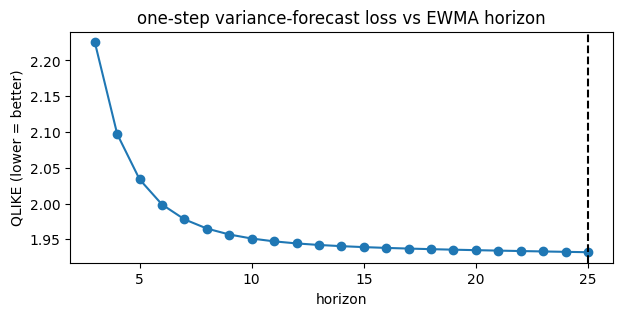

In [3]:
scores = regime.calibrate_horizon(x_usd, y_usd, horizons=range(3, 26))
HORIZON = regime.best_horizon(scores, "qlike")
print("calibrated horizon (QLIKE-min):", HORIZON, "days   |   MSE-min:", regime.best_horizon(scores, "mse"),
      "   (RiskMetrics daily lambda=0.94 ~ 16 days)")

ax = scores.set_index("horizon")["qlike"].plot(marker="o", figsize=(7, 3),
        title="one-step variance-forecast loss vs EWMA horizon")
ax.axvline(HORIZON, ls="--", color="k"); ax.set_ylabel("QLIKE (lower = better)"); plt.show()

## 3. Daily EWMA volatility, warm-up discarded

Same `cex_volatility` as the block-level control, now on the daily series at the calibrated horizon;
drop the first `BUFFER` days so only the converged, bias-free year remains.

In [4]:
vol = modeling.cex_volatility(x_usd, y_usd, horizon_min=HORIZON)
vol = vol[vol["time"] >= REGIME_START].reset_index(drop=True)   # drop the warm-up buffer by date
print("vol series (buffer discarded):", vol.shape)
vol.tail()

vol series (buffer discarded): (365, 2)


,time,ewma_vol
360,2026-06-26 00:00:00+00:00,0.029053
361,2026-06-27 00:00:00+00:00,0.028484
362,2026-06-28 00:00:00+00:00,0.027921
363,2026-06-29 00:00:00+00:00,0.027834
364,2026-06-30 00:00:00+00:00,0.027743


## 4. Rolling-median smoothing & tercile classification

Centered 7-day rolling median → the regime signal; label each day by the 33% / 67% quantiles of it.

In [5]:
daily = regime.classify_regimes(vol, window=WINDOW)

lo = daily.loc[daily.regime == "low", "roll_med"].max()
hi = daily.loc[daily.regime == "high", "roll_med"].min()
print(f"tercile cutoffs:  low <= {lo:.5f}   |   high > {hi:.5f}")
print("regime day counts:", daily.regime.value_counts().to_dict())
print()
print("rolling-median vol distribution:")
print(daily["roll_med"].describe().round(6))

tercile cutoffs:  low <= 0.03252   |   high > 0.03698
regime day counts: {'mid': 121, 'low': 120, 'high': 119}

rolling-median vol distribution:
count    360.000000
mean       0.034864
std        0.006358
min        0.020854
25%        0.031231
50%        0.034399
75%        0.038416
max        0.052150
Name: roll_med, dtype: float64


## 5. Enumerate & rank candidate windows

Every ≥7-day run per regime, ranked deepest-into-the-tercile first (recency breaks ties). `rank == 1`
is the strongest candidate; the rest are the fallback menu.

In [6]:
candidates = regime.select_windows(daily, window=WINDOW)
candidates[["regime", "rank", "start", "end", "length", "depth", "win_start", "win_end"]]

,regime,rank,start,end,length,depth,win_start,win_end
0,high,1,2026-02-01 00:00:00+00:00,2026-03-28 00:00:00+00:00,56,0.043881,2026-02-26 00:00:00+00:00,2026-03-03 00:00:00+00:00
1,high,2,2025-08-20 00:00:00+00:00,2025-09-09 00:00:00+00:00,21,0.041613,2025-08-27 00:00:00+00:00,2025-09-01 00:00:00+00:00
2,high,3,2025-10-11 00:00:00+00:00,2025-10-26 00:00:00+00:00,16,0.040471,2025-10-16 00:00:00+00:00,2025-10-21 00:00:00+00:00
3,high,4,2025-11-04 00:00:00+00:00,2025-11-24 00:00:00+00:00,21,0.038525,2025-11-11 00:00:00+00:00,2025-11-16 00:00:00+00:00
4,low,1,2026-04-23 00:00:00+00:00,2026-06-06 00:00:00+00:00,45,0.025502,2026-05-12 00:00:00+00:00,2026-05-17 00:00:00+00:00
5,low,2,2025-12-24 00:00:00+00:00,2026-01-30 00:00:00+00:00,38,0.028507,2026-01-09 00:00:00+00:00,2026-01-14 00:00:00+00:00
6,low,3,2026-06-13 00:00:00+00:00,2026-06-28 00:00:00+00:00,16,0.030337,2026-06-18 00:00:00+00:00,2026-06-23 00:00:00+00:00
7,low,4,2025-07-26 00:00:00+00:00,2025-08-04 00:00:00+00:00,10,0.031477,2025-07-28 00:00:00+00:00,2025-08-02 00:00:00+00:00
8,low,5,2025-10-03 00:00:00+00:00,2025-10-09 00:00:00+00:00,7,0.032216,2025-10-03 00:00:00+00:00,2025-10-08 00:00:00+00:00
9,mid,1,2026-03-29 00:00:00+00:00,2026-04-22 00:00:00+00:00,25,0.034481,2026-04-07 00:00:00+00:00,2026-04-12 00:00:00+00:00


## 6. Select one confound-dodging window per regime

`pick_windows` takes each regime's best run whose 7-day window can be slid to avoid the confound
dates, else falls back to the next run. Monthly options expiry (last Friday) is auto-computed; add
FOMC / CPI dates by hand via `.union([...])`. `avoided = True` means the chosen window clears every
confound.

In [7]:
confounds = regime.monthly_expiries(daily.time.min(), daily.time.max())


picks = regime.pick_windows(candidates, avoid=confounds, window=WINDOW)
picks

,regime,chosen_rank,win_start,win_end,run_start,run_end,depth,avoided
0,high,1,2026-02-28 00:00:00+00:00,2026-03-05 00:00:00+00:00,2026-02-01 00:00:00+00:00,2026-03-28 00:00:00+00:00,0.043881,True
1,low,1,2026-05-12 00:00:00+00:00,2026-05-17 00:00:00+00:00,2026-04-23 00:00:00+00:00,2026-06-06 00:00:00+00:00,0.025502,True
2,mid,1,2026-04-07 00:00:00+00:00,2026-04-12 00:00:00+00:00,2026-03-29 00:00:00+00:00,2026-04-22 00:00:00+00:00,0.034481,True


In [8]:
confounds

DatetimeIndex(['2025-07-25 00:00:00+00:00', '2025-08-29 00:00:00+00:00',
               '2025-09-26 00:00:00+00:00', '2025-10-31 00:00:00+00:00',
               '2025-11-28 00:00:00+00:00', '2025-12-26 00:00:00+00:00',
               '2026-01-30 00:00:00+00:00', '2026-02-27 00:00:00+00:00',
               '2026-03-27 00:00:00+00:00', '2026-04-24 00:00:00+00:00',
               '2026-05-29 00:00:00+00:00', '2026-06-26 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

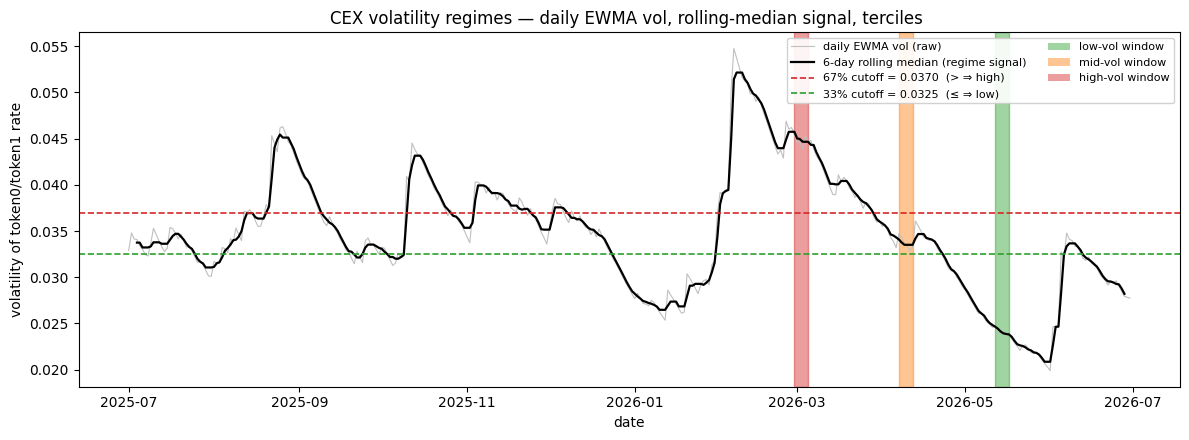

In [9]:
regime.plot_regimes(daily, picks, window=WINDOW)
plt.show()

## 7. Save the three chosen windows

Write one row per regime to `S.study_dates_path` — a **pair-level, regime-shared** file
(`<chain>/<pair>/study_dates.csv`, *outside* the `<regime>_vol/` folders since the windows don't
depend on the active regime). Every regime's extract/transform reads it from here.

In [10]:
regime.save_study_windows(picks, S.study_dates_path)

Saved 3 regime windows to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDT/study_dates.csv


## Is the shape plausible?

Yes. The rate `R ≈ USDC/USD ÷ ETH/USD` is dominated by ETH volatility (USDC barely moves), so this is
essentially a year of ETH realized vol — which genuinely clusters and mean-reverts (spikes that decay
over 1–3 weeks, several times a year). Both potential biases are handled: the EWMA cold-start is
pushed out of view by the warm-up discard, and the horizon is set by a standard forecast-error rule.

**Scope.** A pragmatic threshold-based classifier used to select representative sub-samples, not a
formal regime model (a Markov-switching-in-variance model would identify regimes endogenously — the
natural extension if the regime definition itself were the object of study). Window selection is
descriptive and ex-post, so the centered rolling median is appropriate.